## **显示图片**


(70000, 785)
特征数据:  (70000, 784)
该索引对应的图片是: 1
所有标签的个数:  Counter({1: 7877, 7: 7293, 3: 7141, 2: 6990, 9: 6958, 0: 6903, 6: 6876, 8: 6825, 4: 6824, 5: 6313})


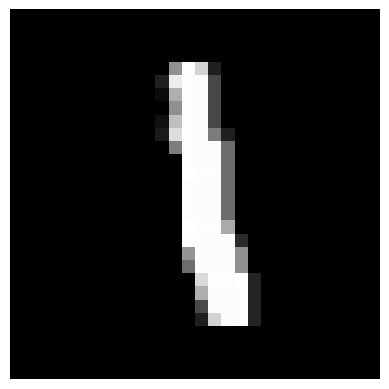

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


def show_image(index):
    """
    显示图片
    :param index: 索引
    :return:
    """
    df = pd.read_csv('./data/mnist_784.csv')
    print(df.shape)
    if index < 0 or index > len(df):
        print("索引超出范围")
        return
    x = df.iloc[:, :-1]  # 获取特征数据,所有行,去掉最后一列
    y = df.iloc[:, -1]  # 获取标签数据,所有行,最后一列
    print('特征数据: ', x.shape)
    print('该索引对应的图片是:', y.iloc[index])
    print('所有标签的个数: ', Counter(y))
    # 将图片数据还原成二维图片
    image = x.iloc[index].values.reshape(28, 28)
    plt.imshow(image, cmap='gray')  # 灰度图
    plt.axis('off')  # 不显示坐标轴
    plt.show()


show_image(6)

## **训练模型**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import joblib

# 1.加载数据
df = pd.read_csv('./data/mnist_784.csv')
x = df.iloc[:, :-1]  # 特征
y = df.iloc[:, -1]  # 标签

# 2.预处理数据,归一化
x = x / 255  # 归一化公式：x_new = (x - x_min) / (x_max - x_min)

# 3.划分数据集
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 参考y轴进行抽取,保持测试集和训练集的标签比例一致(数据均衡)
)

# 4.训练模型
# 创建模型对象
estimator = KNeighborsClassifier(n_neighbors=3)
# 训练模型
estimator.fit(x_train, y_train)

# 5.模型评估
print('准确率: ', estimator.score(x_test, y_test))
print('准确率: ', accuracy_score(y_test, estimator.predict(x_test)))

# 6.保存模型
joblib.dump(estimator, './model/knn.pkl')  # pickle文件
print('模型保存成功')

## 使用模型

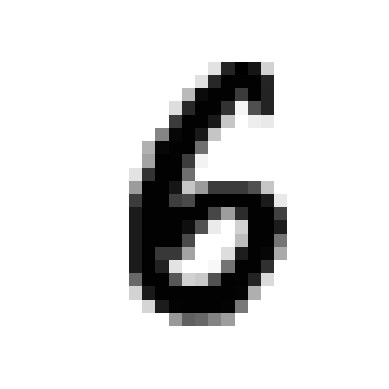

预测结果:  [6]


D:\workspaces\pycharm\venv\MachineLearning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [4]:
import joblib

# 1.加载图片
image = plt.imread('./data/6.bmp')
plt.axis('off')
plt.imshow(image, cmap='gray')
plt.show()
# 2.加载模型
estimator = joblib.load('./model/knn.pkl')
image = 255 - image  # 像素反转,训练模型的数据是黑底白字,但是测试图片是白底黑字
image = image.reshape(1, -1)  # 改变图片的维度 效果和reshape(1,784)相同
image = image / 255  # 归一化,因为训练的时候使用了归一化,测试数据也要归一化
print('预测结果: ', estimator.predict(image))